In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random
from scipy.signal import savgol_filter

In [34]:
CONTEXT = 10

class Pipeline:

    d = None
    d_left = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        self.d_left = self.__calculate_distance(self.x_left, self.y_left)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.d = self.__normalization_min_max_positive(self.d)
        self.d_left = self.__normalization_min_max_positive(self.d_left)
        # self.d = self.__savgol_filter(self.d)
        # print(self.d.isna().sum())
        # self.mask = self.__idt(self.x, self.y, self.t)
        self.mask = self.__contextual_dot_product(self.x_mask, self.y_mask, context=10)
        # self.mask = self.x_mask + self.y_mask

        angular_velocity = self.__calculate_angular_velocity(self.x, self.y)
        angular_velocity_left = self.__calculate_angular_velocity(self.x_left, self.y_left)
        angular_velocity = self.__normalization_min_max(angular_velocity)
        angular_velocity_left = self.__normalization_min_max(angular_velocity_left)
        
        angular_velocity = self.__zero_outliers_fix_threshold(angular_velocity)
        angular_velocity_left = self.__zero_outliers_fix_threshold(angular_velocity_left)
        
        angular_velocity = self.__normalization_min_max_positive(angular_velocity)
        angular_velocity_left = self.__normalization_min_max_positive(angular_velocity_left)
        
        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.y)
        self.x_left = self.__normalization_min_max_positive(self.x_left)
        self.y_left = self.__normalization_min_max_positive(self.y_left)
        
        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        d_saccade = self.__extract_peak_segments(self.d, self.mask, context_size=CONTEXT)
        d_left_saccade = self.__extract_peak_segments(self.d_left, self.mask, context_size=CONTEXT)
        angular_velocity = self.__extract_peak_segments(angular_velocity, self.mask, context_size=CONTEXT)
        angular_velocity_left = self.__extract_peak_segments(angular_velocity_left, self.mask, context_size=CONTEXT)

        # if angular_velocity != [] and angular_velocity_left != []:
        #     angular_velocity = np.concatenate(angular_velocity) if isinstance(angular_velocity, list) else angular_velocity
        #     angular_velocity_left = np.concatenate(angular_velocity_left) if isinstance(angular_velocity_left, list) else angular_velocity_left
        
        # x_saccade = self.__concatenate_signals(x_saccade)
        # y_saccade = self.__concatenate_signals(y_saccade)
        # x_left_saccade = self.__concatenate_signals(x_left_saccade)
        # y_left_saccade = self.__concatenate_signals(y_left_saccade)
        # d_saccade = self.__concatenate_signals(d_saccade)
        # d_left_saccade = self.__concatenate_signals(d_left_saccade)
        # for signal in self.saccade_signals:
        #     nans = np.sum(np.isnan(signal))
        #     if nans != 0:
        #         print(nans)

        # self.saccade_gen = self.__generate_smoothed_signal(self.saccade_signals)

        # self.saccade_seq = next(self.saccade_gen)

        # self.saccade_seq = self.__highpass_filtering(self.saccade_seq)

        # self.saccade_seq = self.__normalization_min_max(self.saccade_seq)
        
        return x_saccade, x_saccade, x_saccade, x_saccade, x_saccade, x_saccade,

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal, lower=5, higher=95):
        Q1 = np.percentile(signal, lower) 
        Q3 = np.percentile(signal, higher)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
        return filtered_signal

    def __zero_outliers_fix_threshold(self, signal, lower=-0.5, upper=0.5):
    
        num_outliers = np.sum((signal < lower) | (signal > upper))
    
        filtered_signal = np.where((signal < lower) | (signal > upper), 0, signal)
        
        return filtered_signal

    
    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

    def __savgol_filter(self, signal):
        return savgol_filter(signal, window_length=11, polyorder=3)
    
    def __idt(self, x, y, t, velocity_threshold=30):
        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)
    
        velocity = np.sqrt(dx**2 + dy**2) / dt  
        velocity = np.insert(velocity, 0, 0)
    
        saccade_mask = velocity > velocity_threshold
        saccade_mask = saccade_mask.astype(int)
    
        return saccade_mask
    
    def __contextual_dot_product(self, signal1, signal2, context):
        assert len(signal1) == len(signal2), "Signals must be of equal length"
    
        # Create a kernel with ones in the given context range
        kernel = np.ones(2 * context + 1)
    
        # Convolve signal2 with the kernel (this spreads 1s over the context)
        spread_signal2 = convolve(signal2, kernel, mode='same')  # 'same' keeps original size
    
        # Convert convolved signal to binary (any nonzero value means a 1 was nearby)
        spread_signal2 = (spread_signal2 > 0).astype(int)
    
        # Perform element-wise AND (dot product-like)
        result = signal1 * spread_signal2
        return result
    
    def __concatenate_signals(self, signals):
        if len(signals) == 0: return []
        return np.concatenate(signals, axis=0)  # Concatenates along the first axis

    def __calculate_angular_velocity(self, x, y):
        theta = np.arctan2(y, x)
        return theta.diff() / self.t.diff()



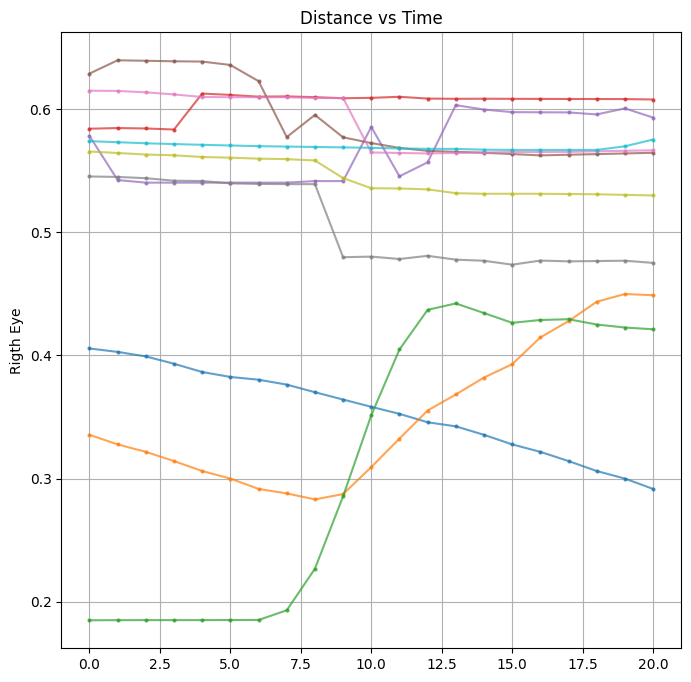

In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

num_features = len(saccade_signals)

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

for signal in saccade_signals[0][:10]:
    axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

# print(len(saccade_seq))

In [4]:
labels_num = 2

In [5]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in range(labels_num):  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521


In [6]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

# Iterate over the 10 labels (00 to 09)
for i in range(labels_num):  
    label = i  # Assign label from 0 to 9
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(100):
            segment = signal[j * 1000 : (j + 1) * 1000].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(1000)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [7]:
df_train_raw = df_processed[df_processed["segment"].between(1, 65)]
df_val_raw = df_processed[df_processed["segment"].between(66,80)]
df_test_raw = df_processed[df_processed["segment"].between(81, 100)]

In [8]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [9]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
80,0,t,81,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
81,0,t,82,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
82,0,t,83,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
83,0,t,84,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
84,0,t,85,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [10]:
df_val_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_990,dim_991,dim_992,dim_993,dim_994,dim_995,dim_996,dim_997,dim_998,dim_999
65,0,t,66,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
66,0,t,67,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
67,0,t,68,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
68,0,t,69,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
69,0,t,70,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


# features generation

In [11]:
# # Select a specific label and segment
# label = df_train_raw["label"].unique()[1]  # Select the first label
# segment = df_train_raw[df_train_raw["label"] == label]["segment"].unique()[2]  # Select the first segment for that label

# # Filter the dataframe for the selected label and segment
# df_segment = df_train_raw[(df_train_raw["label"] == label) & (df_train_raw["segment"] == segment)]

# # Extract input signals based on signal_type
# t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
# x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
# y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
# x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
# y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()

# plt.plot(x)
# print(x.shape)
# print(x[0])
# # Run the pipeline
# pipeline = Pipeline(t, x, y, x_left, y_left)
# x_saccade, y_saccade, d_saccade, angular_velocity, x_left_saccade, y_left_saccade, d_left_saccade, angular_velocity_left = pipeline.run()

# # Print the result
# print("Generated signal:", x_saccade[0])


In [12]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    generated_subsequences = []
    i = 0
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            # for _ in range(10):
            pipeline = Pipeline(t, x, y, x_left, y_left)
            results = pipeline.run()

            # print(f'reults len: {len(results)}')
            assert len(results) == num_features, 'len of resutls is diffrent than 6'
            result_shape = len(results[0])
            for result in results:
                for signal in result:
                    # print(len(signal))
                    # assert len(signal) == 2 * CONTEXT + 1, 'len of signal is inconcisent'
                    assert len(result) == result_shape, 'result shape is inconsitent'
                    # print(f'result shape ({len(result)},{len(signal)})')
            
            # Store the generated signal and label
            for result in results:
                valid_result = [signal for signal in result if len(signal) == 2 * CONTEXT + 1]
                # print(valid_result)
                generated_signals.extend(valid_result)
                generated_labels.extend([label]*len(valid_result))
                # generated_labels.append(label)
                generated_subsequences.extend([i]*len(valid_result))
            i += 1

    # generated_signals = np.vstack(generated_signals)
    # Convert results into DataFrame
    print(len(generated_signals))
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels}), pd.DataFrame(generated_subsequences)

df_train, df_train_labels, df_train_subsequnces = generate_features(df_train_raw)
# df_train = df_train.iloc[:, :1000]

df_test, df_test_labels, df_test_subsequnces = generate_features(df_test_raw)
# df_test = df_test.iloc[:, :1000]

df_val, df_val_labels, df_val_subsequnces = generate_features(df_val_raw)
# df_val = df_val.iloc[:, :1000]

1544
384
396


In [13]:
df_train_raw['segment'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65])

In [14]:
df_train_labels['label'].unique()

array([0, 1])

In [15]:
print(df_train.shape)
print(df_train_labels.shape)
print(df_train_subsequnces.shape)

(1544, 21)
(1544, 1)
(1544, 1)


In [16]:
df_train_subsequnces[0].unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129])

In [17]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.534539,0.531204,0.523989,0.512232,0.501682,0.491315,0.485371,0.479232,0.471171,0.458098,...,0.434515,0.429595,0.420818,0.407265,0.394169,0.381165,0.368641,0.353565,0.346305,0.331144
1,0.492562,0.496567,0.490137,0.519755,0.567791,0.636697,0.708252,0.764761,0.819862,0.870311,...,0.933056,0.952686,0.951164,0.938114,0.916116,0.916819,0.896726,0.877760,0.878968,0.878201
2,0.842432,0.842758,0.843262,0.843422,0.843771,0.844120,0.844789,0.844909,0.844932,0.845253,...,0.840870,0.819805,0.820291,0.821269,0.822030,0.821492,0.820949,0.819541,0.814118,0.814501
3,0.534539,0.531204,0.523989,0.512232,0.501682,0.491315,0.485371,0.479232,0.471171,0.458098,...,0.434515,0.429595,0.420818,0.407265,0.394169,0.381165,0.368641,0.353565,0.346305,0.331144
4,0.492562,0.496567,0.490137,0.519755,0.567791,0.636697,0.708252,0.764761,0.819862,0.870311,...,0.933056,0.952686,0.951164,0.938114,0.916116,0.916819,0.896726,0.877760,0.878968,0.878201


In [18]:
df_train = df_train.fillna(df_train.mean())
df_test = df_test.fillna(df_test.mean())
df_val = df_val.fillna(df_val.mean())

In [19]:
df_train.isna().sum().sum()

np.int64(0)

In [20]:
df_train_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [21]:
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.290659,0.278235,0.273679,0.266988,0.263290,0.258028,0.253236,0.252564,0.251656,0.246142,...,0.238963,0.239871,0.242594,0.244057,0.248916,0.249050,0.249470,0.251202,0.249823,0.248109
1,0.585421,0.585589,0.586732,0.588161,0.589792,0.600686,0.586009,0.581134,0.579032,0.672607,...,0.654248,0.660771,0.665277,0.660788,0.657779,0.675078,0.685384,0.682374,0.678289,0.678525
2,0.574964,0.572173,0.567314,0.563397,0.557765,0.551293,0.548939,0.547695,0.563902,0.625315,...,0.660906,0.636798,0.612236,0.610571,0.601224,0.591372,0.585606,0.546064,0.540870,0.532363
3,0.212619,0.209795,0.207222,0.207071,0.206298,0.198363,0.203894,0.179382,0.185081,0.180542,...,0.171010,0.154837,0.109781,0.097256,0.086581,0.061834,0.021788,0.000000,0.149222,0.144329
4,0.290659,0.278235,0.273679,0.266988,0.263290,0.258028,0.253236,0.252564,0.251656,0.246142,...,0.238963,0.239871,0.242594,0.244057,0.248916,0.249050,0.249470,0.251202,0.249823,0.248109


In [22]:
df_test_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [23]:
# shuffled_indices = df_train.sample(frac=1, random_state=42).index

# df_train = df_train.loc[shuffled_indices].reset_index(drop=True)
# df_train_labels = df_train_labels.loc[shuffled_indices].reset_index(drop=True)

# shuffled_indices = df_test.sample(frac=1, random_state=42).index

# df_test = df_test.loc[shuffled_indices].reset_index(drop=True)
# df_test_labels = df_test_labels.loc[shuffled_indices].reset_index(drop=True)

# shuffled_indices = df_val.sample(frac=1, random_state=42).index

# df_val = df_val.loc[shuffled_indices].reset_index(drop=True)
# df_val_labels = df_val_labels.loc[shuffled_indices].reset_index(drop=True)

In [24]:
# def shuffle_dataframe_grouped(df, df_labels, group_size=4, random_state=42):
#     # Step 1: Compute group indices (every 4 rows are one group)
#     num_groups = len(df) // group_size
#     group_indices = np.arange(num_groups)

#     # Step 2: Shuffle group indices
#     np.random.seed(random_state)
#     np.random.shuffle(group_indices)

#     # Step 3: Reconstruct dataframe and labels in shuffled order
#     shuffled_df = pd.concat([df.iloc[i * group_size : (i + 1) * group_size] for i in group_indices]).reset_index(drop=True)
#     shuffled_labels = pd.concat([df_labels.iloc[i * group_size : (i + 1) * group_size] for i in group_indices]).reset_index(drop=True)

#     return shuffled_df, shuffled_labels

# # Apply to train, test, and validation sets
# df_train, df_train_labels = shuffle_dataframe_grouped(df_train, df_train_labels, group_size=num_features)
# df_test, df_test_labels = shuffle_dataframe_grouped(df_test, df_test_labels, group_size=num_features)
# df_val, df_val_labels = shuffle_dataframe_grouped(df_val, df_val_labels, group_size=num_features)

In [25]:
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence

def transform_data(df_signals, df_labels, df_subsequences, num_derivatives):
    """
    Transforms dataset into shape:
    (num_segments, max_num_subsequences, num_derivatives, subsequence_length)

    - Groups sequences by segment.
    - Handles **variable numbers of subsequences per segment**.
    - Uses **zero-padding for shorter segments** (no duplication).
    """
    X_list = []
    y_list = []
    
    unique_segments = df_subsequences.iloc[:, 0].unique()  # Unique segment IDs
    
    for segment_id in unique_segments:
        mask = df_subsequences.iloc[:, 0] == segment_id  # Select all subsequences from the same segment
        
        subset = df_signals[mask].values  # Extract signal values
        label = df_labels[mask].iloc[0, 0]  # Get segment label

        num_subsequences = subset.shape[0] // num_derivatives  # Determine subsequences per segment
        subsequence_length = subset.shape[1]  # Fixed at 7

        if subset.shape[0] % num_derivatives != 0:
            print(f"Skipping segment {segment_id} due to inconsistent shape: {subset.shape}")
            continue  # Skip problematic segments

        subset = subset.reshape(num_subsequences, num_derivatives, subsequence_length)

        X_list.append(torch.tensor(subset, dtype=torch.float32))  # Store all subsequences from this segment
        y_list.append(label)  # Store one label per segment

    # Find max_num_subsequences per segment for padding
    max_num_subsequences = max(seq.shape[0] for seq in X_list)

    # Pad sequences to match the longest subsequence count
    X_padded = pad_sequence(
        X_list, 
        batch_first=True, 
        padding_value=0.0
    )  # Shape: (num_segments, max_num_subsequences, num_derivatives, subsequence_length)

    y = np.array(y_list, dtype=np.int64)  # Convert labels to NumPy array

    return X_padded, y

# Number of derivatives = 6
num_derivatives = num_features

# Transform Training, Validation, and Test Data
X_train, y_train = transform_data(df_train, df_train_labels, df_train_subsequnces, num_derivatives)
X_val, y_val = transform_data(df_val, df_val_labels, df_val_subsequnces, num_derivatives)
X_test, y_test = transform_data(df_test, df_test_labels, df_test_subsequnces, num_derivatives)

# Print Shapes
print("X_train shape:", X_train.shape)  # (num_segments, max_num_subsequences, num_derivatives, subsequence_length)
print("y_train shape:", y_train.shape)  # (num_segments,)


X_train shape: torch.Size([130, 7, 4, 21])
y_train shape: (130,)


In [26]:
X_train[0].shape

torch.Size([7, 4, 21])

## Deep Learning

In [27]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

neurons = np.array([1, 2, 4, 8, 16]) * 128

class NN(nn.Module):
    def __init__(self, num_classes, num_derivatives, num_subsequences):
        super(NN, self).__init__()

        # Conv2D expects: (batch_size, num_derivatives, num_subsequences, subsequence_length)
        self.conv1 = nn.Conv2d(in_channels=num_derivatives, out_channels=neurons[0], kernel_size=(5, 8), stride=(1, 1), padding=(1, 1))
        self.bn1 = nn.BatchNorm2d(neurons[0])

        self.conv2 = nn.Conv2d(neurons[0], neurons[1], kernel_size=(3, 8), stride=(1, 1), padding=(1, 1))
        self.bn2 = nn.BatchNorm2d(neurons[1])

        self.conv3 = nn.Conv2d(neurons[1], neurons[2], kernel_size=(3, 4), stride=(1, 1), padding=(1, 1))
        self.bn3 = nn.BatchNorm2d(neurons[2])

        # Pooling to reduce only `subsequence_length` (7 → 4 → 2)
        self.pool = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 1))  # Reduces only time dimension

        # Global Adaptive Pooling (ensures fixed-size output)
        self.global_pool = nn.AdaptiveAvgPool2d((num_subsequences, 1))  # (batch, channels, num_subsequences, 1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(neurons[2] * num_subsequences, neurons[3])

        self.dropout1 = nn.Dropout(0.05)
        
        self.fc2 = nn.Linear(neurons[3], neurons[4])
        self.fc3 = nn.Linear(neurons[4], num_classes)

    def forward(self, x):
        
        x = x.permute(0, 2, 1, 3)  # Swap to (batch_size, num_derivatives, num_subsequences, subsequence_length) (0,2,1,3)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        # Global Average Pooling across subsequence_length
        x = self.global_pool(x)  # (batch_size, neurons[2], num_subsequences, 1)

        # Flatten before fully connected layers
        x = x.view(x.size(0), -1)  # (batch_size, neurons[2] * num_subsequences)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.dropout1(x)
        x = self.fc3(x)

        return x

/tmp/ipykernel_24329/3020874979.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X)  # No unsqueeze(1), we now have multiple features per timestamp


Epoch 1/8, Loss: 7.3575, Accuracy: 51.54%
Epoch 2/8, Loss: 5.9838, Accuracy: 53.08%
Epoch 3/8, Loss: 5.7478, Accuracy: 63.08%
Epoch 4/8, Loss: 5.8838, Accuracy: 56.92%
Epoch 5/8, Loss: 5.4950, Accuracy: 60.00%
Epoch 6/8, Loss: 5.1988, Accuracy: 70.00%
Epoch 7/8, Loss: 5.4410, Accuracy: 72.31%
Epoch 8/8, Loss: 5.8459, Accuracy: 73.85%
Test Accuracy: 43.24%

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.41      0.40        17
           1       0.47      0.45      0.46        20

    accuracy                           0.43        37
   macro avg       0.43      0.43      0.43        37
weighted avg       0.43      0.43      0.43        37



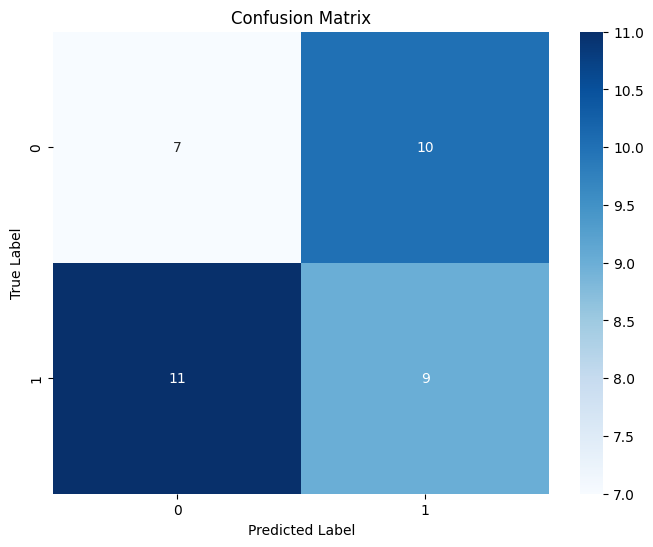

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# X_train = df_train.values.astype(np.float32)
# y_train = df_train_labels["label"].values[::num_features].astype(np.int64)

# X_val = df_val.values.astype(np.float32)
# y_val = df_val_labels["label"].values[::num_features].astype(np.int64)

# X_test = df_test.values.astype(np.float32)
# y_test = df_test_labels["label"].values[::num_features].astype(np.int64)

# num_features_per_row = X_train.shape[1]
# # print(num_features_per_row)

# X_train = X_train.reshape(-1, num_features, num_features_per_row)  # ✅ Now shape is (num_samples, 4, sequence_length)
# X_val = X_val.reshape(-1, num_features, num_features_per_row)
# X_test = X_test.reshape(-1, num_features, num_features_per_row)

# print(X_train.shape)
# print(y_train.shape)

# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)  # No unsqueeze(1), we now have multiple features per timestamp
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
test_dataset = SignalDataset(X_test, y_test)
val_dataset = SignalDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(np.unique(y_train))
num_subsequences = X_train.shape[1]  # Extracted subsequences per sample
subsequence_length = X_train.shape[3]  # Time steps

model = NN(num_classes, num_derivatives, num_subsequences).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=8)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)


Epoch 1/50 - Loss: 7.1440 - Train Acc: 49.23% - Val AUC-ROC: 0.2667
✅ New Best Model Saved! AUC-ROC: 0.2667
Epoch 2/50 - Loss: 6.4195 - Train Acc: 48.46% - Val AUC-ROC: 0.2978
✅ New Best Model Saved! AUC-ROC: 0.2978
Epoch 3/50 - Loss: 6.3235 - Train Acc: 49.23% - Val AUC-ROC: 0.2978
⏳ Early Stopping Counter: 1/5
Epoch 4/50 - Loss: 5.6093 - Train Acc: 62.31% - Val AUC-ROC: 0.3511
✅ New Best Model Saved! AUC-ROC: 0.3511
Epoch 5/50 - Loss: 5.4704 - Train Acc: 66.92% - Val AUC-ROC: 0.3244
⏳ Early Stopping Counter: 1/5
Epoch 6/50 - Loss: 5.4729 - Train Acc: 62.31% - Val AUC-ROC: 0.3378
⏳ Early Stopping Counter: 2/5
Epoch 7/50 - Loss: 4.9477 - Train Acc: 68.46% - Val AUC-ROC: 0.3556
✅ New Best Model Saved! AUC-ROC: 0.3556
Epoch 8/50 - Loss: 4.7403 - Train Acc: 73.85% - Val AUC-ROC: 0.3378
⏳ Early Stopping Counter: 1/5
Epoch 9/50 - Loss: 4.5125 - Train Acc: 72.31% - Val AUC-ROC: 0.5378
✅ New Best Model Saved! AUC-ROC: 0.5378
Epoch 10/50 - Loss: 6.2434 - Train Acc: 65.38% - Val AUC-ROC: 0.2844

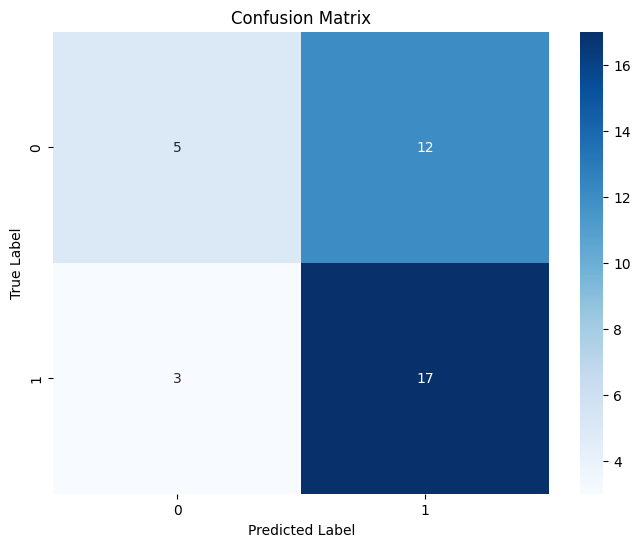

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import Dataset, DataLoader

# Model Setup
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(num_classes, num_derivatives, num_subsequences).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Training with Early Stopping & AUC-ROC Monitoring
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5):
    best_auc_roc = 0.0
    patience_counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = 100 * correct / total
        val_auc_roc = evaluate_auc_roc(model, val_loader, num_classes)  # Compute AUC-ROC

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Val AUC-ROC: {val_auc_roc:.4f}")

        # Early Stopping Logic
        if val_auc_roc > best_auc_roc:
            best_auc_roc = val_auc_roc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)  # Save Best Model
            print(f"✅ New Best Model Saved! AUC-ROC: {best_auc_roc:.4f}")
        else:
            patience_counter += 1
            print(f"⏳ Early Stopping Counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"⏹️ Early Stopping Triggered! Best AUC-ROC: {best_auc_roc:.4f}")
            break

    print("🎉 Training Complete!")

from sklearn.preprocessing import label_binarize

def evaluate_auc_roc(model, val_loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Get class probabilities

            all_preds.extend(probabilities)  # Collect all probability distributions
            all_labels.extend(y_batch.cpu().numpy())  # Collect true labels

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Binarize labels for AUC-ROC calculation (for multiclass OvO)
    all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

    # Compute AUC-ROC using One-vs-One (OvO) strategy
    if num_classes > 2:
        return roc_auc_score(all_labels_bin, all_preds, multi_class='ovo')
    else:
        return roc_auc_score(all_labels, all_preds[:, 1])  # Use standard binary AUC-ROC if only two classes


# Train Model
train_model(model, train_loader, val_loader, num_epochs=50, patience=5)

# Load Best Model and Evaluate on Test Set
best_model = NN(num_classes, num_derivatives, num_subsequences).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()

from sklearn.metrics import precision_recall_fscore_support

def evaluate_model(model, test_loader, num_classes):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Class probabilities
            _, predicted = torch.max(outputs, 1)  # Predicted class

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_probs.extend(probabilities)  # Store probabilities for AUC-ROC
            all_preds.extend(predicted.cpu().numpy())  # Store predicted labels
            all_labels.extend(y_batch.cpu().numpy())  # Store true labels

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Compute Accuracy
    accuracy = 100 * correct / total

    # Compute AUC-ROC using OvO for Multiclass
    if num_classes > 2:
        all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))
        auc_roc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovo')
    else:
        auc_roc = roc_auc_score(all_labels, all_probs[:, 1]) if len(set(all_labels)) > 1 else 0.0  # Binary case

    # Compute Precision, Recall, F1-score for each class
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"Test Accuracy: {accuracy:.2f}%, Test AUC-ROC: {auc_roc:.4f}")
    print(f"\nMacro Avg Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1-score: {macro_f1:.4f}")
    print(f"Weighted Avg Precision: {weighted_precision:.4f}, Recall: {weighted_recall:.4f}, F1-score: {weighted_f1:.4f}")

    # Display Per-Class Metrics
    for i in range(num_classes):
        print(f"Class {i}: Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Evaluate Best Model
evaluate_model(best_model, test_loader, num_classes)


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import optuna
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ✅ Define Dataset Class
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ✅ Define CNN Model
class CNN(nn.Module):
    def __init__(self, num_classes, num_derivatives, num_subsequences, config):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=num_derivatives, out_channels=config["neurons"][0], 
                               kernel_size=config["kernel1"], stride=(1, 2), padding=(1, 1))
        self.bn1 = nn.BatchNorm2d(config["neurons"][0])

        self.conv2 = nn.Conv2d(config["neurons"][0], config["neurons"][1], 
                               kernel_size=config["kernel2"], stride=(1, 1), padding=(1, 1))
        self.bn2 = nn.BatchNorm2d(config["neurons"][1])

        self.conv3 = nn.Conv2d(config["neurons"][1], config["neurons"][2], 
                               kernel_size=config["kernel3"], stride=(1, 1), padding=(1, 1))
        self.bn3 = nn.BatchNorm2d(config["neurons"][2])

        self.pool = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))
        self.global_pool = nn.AdaptiveAvgPool2d((num_subsequences, 1))

        self.fc1 = nn.Linear(config["neurons"][2] * num_subsequences, config["neurons"][3])
        self.dropout = nn.Dropout(config["dropout"])
        self.fc2 = nn.Linear(config["neurons"][3], config["neurons"][4])
        self.fc3 = nn.Linear(config["neurons"][4], num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1, 3)  # (batch, derivatives, subsequences, length)

        x = nn.ReLU()(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = nn.ReLU()(self.bn2(self.conv2(x)))
        x = self.pool(x)
        
        x = nn.ReLU()(self.bn3(self.conv3(x)))
        x = self.pool(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = nn.ReLU()(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

# ✅ Training function
def train_model(config, train_loader, val_loader, device):
    num_classes = len(np.unique(y_train))
    num_subsequences = X_train.shape[1]

    model = CNN(num_classes=num_classes, num_derivatives=num_features, 
                num_subsequences=num_subsequences, config=config).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    for epoch in range(10):
        model.train()
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = correct / total

        # ✅ Validation Loop
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                outputs = model(X_val)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_val).sum().item()
                val_total += y_val.size(0)

        val_accuracy = val_correct / val_total
        print(f"Epoch {epoch+1}, Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

    return val_accuracy, model  # ✅ Return the trained model and validation accuracy

# ✅ Hyperparameter Optimization using Optuna
def objective(trial):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 📌 Define Search Space
    config = {
        "neurons": trial.suggest_categorical("neurons", [
            [128, 256, 512, 1024, 2048],
            [64, 128, 256, 512, 1024],
            [32, 64, 128, 256, 512],
            [512, 256, 128, 64, 32],
            [1024, 512, 256, 128, 64],
            [2048, 1024, 512, 256, 128]
        ]),
        "kernel1": trial.suggest_categorical("kernel1", [(3, 7), (5, 7), (3, 5)]),
        "kernel2": trial.suggest_categorical("kernel2", [(5, 3), (3, 3), (3, 2)]),
        "kernel3": trial.suggest_categorical("kernel3", [(3, 2), (3, 3), (2, 3)]),
        "lr": trial.suggest_loguniform("lr", 1e-5, 1e-3),
        "dropout": trial.suggest_uniform("dropout", 0.05, 0.2),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32, 64]),
        "epochs": 10,
        "num_derivatives": num_derivatives,
    }

    # 📌 Create DataLoaders
    train_dataset = SignalDataset(X_train, y_train)
    val_dataset = SignalDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    # 📌 Train Model
    val_accuracy, _ = train_model(config, train_loader, val_loader, device)

    return val_accuracy  # ✅ Optuna will maximize this metric

# ✅ Run Hyperparameter Search
study = optuna.create_study(direction="maximize")  # 📌 Maximize validation accuracy
study.optimize(objective, n_trials=50)  # 📌 Run 20 trials

# 📌 Best Configuration
print("Best trial:")
print(study.best_trial.params)

# ✅ Train Final Model with Best Config
best_config = study.best_trial.params
train_dataset = SignalDataset(X_train, y_train)
test_dataset = SignalDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=best_config["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_config["batch_size"], shuffle=False)

_, final_model = train_model(best_config, train_loader, test_loader, device)

# ✅ Save the Best Model
torch.save(final_model.state_dict(), "best_cnn_model.pth")
print("Best model saved as best_cnn_model.pth")


[I 2025-03-05 17:32:17,213] A new study created in memory with name: no-name-6117a6ec-4b6b-4c2c-8eba-b7c07ad440ba
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [128, 256, 512, 1024, 2048] which is of type list.
  warnings.warn(message)
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64, 128, 256, 512, 1024] which is of type list.
  warnings.warn(message)
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution

Epoch 1, Train Acc: 0.4462, Val Acc: 0.5000
Epoch 2, Train Acc: 0.5769, Val Acc: 0.5000
Epoch 3, Train Acc: 0.5615, Val Acc: 0.5000
Epoch 4, Train Acc: 0.6000, Val Acc: 0.5000
Epoch 5, Train Acc: 0.6077, Val Acc: 0.5000
Epoch 6, Train Acc: 0.5692, Val Acc: 0.5000
Epoch 7, Train Acc: 0.5769, Val Acc: 0.4333
Epoch 8, Train Acc: 0.6308, Val Acc: 0.4667
Epoch 9, Train Acc: 0.6846, Val Acc: 0.3667
Epoch 10, Train Acc: 0.5769, Val Acc: 0.3333
Epoch 1, Train Acc: 0.5231, Val Acc: 0.5000
Epoch 2, Train Acc: 0.4923, Val Acc: 0.5000
Epoch 3, Train Acc: 0.5538, Val Acc: 0.5667
Epoch 4, Train Acc: 0.5538, Val Acc: 0.4667
Epoch 5, Train Acc: 0.6077, Val Acc: 0.6333
Epoch 6, Train Acc: 0.6154, Val Acc: 0.5667
Epoch 7, Train Acc: 0.5769, Val Acc: 0.5667
Epoch 8, Train Acc: 0.6231, Val Acc: 0.5333
Epoch 9, Train Acc: 0.6538, Val Acc: 0.5333


[I 2025-03-05 17:32:18,280] Trial 1 finished with value: 0.4666666666666667 and parameters: {'neurons': [32, 64, 128, 256, 512], 'kernel1': (3, 5), 'kernel2': (3, 2), 'kernel3': (3, 2), 'lr': 2.444917937836557e-05, 'dropout': 0.1723552194114522, 'batch_size': 8}. Best is trial 1 with value: 0.4666666666666667.


Epoch 10, Train Acc: 0.5846, Val Acc: 0.4667
Epoch 1, Train Acc: 0.4077, Val Acc: 0.5000
Epoch 2, Train Acc: 0.4692, Val Acc: 0.5000
Epoch 3, Train Acc: 0.4846, Val Acc: 0.6333
Epoch 4, Train Acc: 0.5077, Val Acc: 0.5000
Epoch 5, Train Acc: 0.5462, Val Acc: 0.3667
Epoch 6, Train Acc: 0.5846, Val Acc: 0.4000
Epoch 7, Train Acc: 0.5692, Val Acc: 0.5000
Epoch 8, Train Acc: 0.5769, Val Acc: 0.4333
Epoch 9, Train Acc: 0.6000, Val Acc: 0.5000


[I 2025-03-05 17:32:19,407] Trial 2 finished with value: 0.4666666666666667 and parameters: {'neurons': [128, 256, 512, 1024, 2048], 'kernel1': (5, 7), 'kernel2': (5, 3), 'kernel3': (3, 2), 'lr': 0.00045307991248397337, 'dropout': 0.18872294648957072, 'batch_size': 8}. Best is trial 1 with value: 0.4666666666666667.


...

Epoch 8, Train Acc: 0.7077, Val Acc: 0.3333
Epoch 9, Train Acc: 0.6846, Val Acc: 0.4667
Epoch 10, Train Acc: 0.7000, Val Acc: 0.4667


[I 2025-03-05 17:32:53,817] Trial 48 finished with value: 0.43333333333333335 and parameters: {'neurons': [512, 256, 128, 64, 32], 'kernel1': (3, 5), 'kernel2': (3, 2), 'kernel3': (3, 2), 'lr': 7.172659624537204e-05, 'dropout': 0.12342988677358105, 'batch_size': 64}. Best is trial 3 with value: 0.5333333333333333.


Epoch 1, Train Acc: 0.5000, Val Acc: 0.5000
Epoch 2, Train Acc: 0.6077, Val Acc: 0.5000
Epoch 3, Train Acc: 0.5692, Val Acc: 0.5000
Epoch 4, Train Acc: 0.5923, Val Acc: 0.5000
Epoch 5, Train Acc: 0.6692, Val Acc: 0.5000
Epoch 6, Train Acc: 0.6077, Val Acc: 0.5000
Epoch 7, Train Acc: 0.5692, Val Acc: 0.5000
Epoch 8, Train Acc: 0.6077, Val Acc: 0.5000
Epoch 9, Train Acc: 0.6000, Val Acc: 0.5000
Epoch 10, Train Acc: 0.6231, Val Acc: 0.4333
Epoch 1, Train Acc: 0.5231, Val Acc: 0.4000
Epoch 2, Train Acc: 0.5692, Val Acc: 0.4000
Epoch 3, Train Acc: 0.5769, Val Acc: 0.3333
Epoch 4, Train Acc: 0.6385, Val Acc: 0.3667
Epoch 5, Train Acc: 0.7077, Val Acc: 0.3667
Epoch 6, Train Acc: 0.6385, Val Acc: 0.4333
Epoch 7, Train Acc: 0.6615, Val Acc: 0.4667
Epoch 8, Train Acc: 0.6692, Val Acc: 0.4000


[I 2025-03-05 17:32:54,838] Trial 49 finished with value: 0.43333333333333335 and parameters: {'neurons': [128, 256, 512, 1024, 2048], 'kernel1': (3, 7), 'kernel2': (3, 3), 'kernel3': (2, 3), 'lr': 1.0033781961951488e-05, 'dropout': 0.09591939425889877, 'batch_size': 8}. Best is trial 3 with value: 0.5333333333333333.


Epoch 9, Train Acc: 0.7385, Val Acc: 0.4667
Epoch 10, Train Acc: 0.7000, Val Acc: 0.4333
Best trial:
{'neurons': [128, 256, 512, 1024, 2048], 'kernel1': (3, 7), 'kernel2': (3, 2), 'kernel3': (2, 3), 'lr': 0.0001596637571791978, 'dropout': 0.0548994078399575, 'batch_size': 8}
Epoch 1, Train Acc: 0.4308, Val Acc: 0.5405
Epoch 2, Train Acc: 0.5462, Val Acc: 0.5135
Epoch 3, Train Acc: 0.5000, Val Acc: 0.5405
Epoch 4, Train Acc: 0.6000, Val Acc: 0.4865
Epoch 5, Train Acc: 0.6462, Val Acc: 0.5676
Epoch 6, Train Acc: 0.5692, Val Acc: 0.5405
Epoch 7, Train Acc: 0.5538, Val Acc: 0.4865
Epoch 8, Train Acc: 0.6692, Val Acc: 0.4595
Epoch 9, Train Acc: 0.6692, Val Acc: 0.4595
Epoch 10, Train Acc: 0.6769, Val Acc: 0.5135
Best model saved as best_cnn_model.pth


Test Accuracy: 51.35%, Test AUC-ROC: 0.5029

Macro Avg Precision: 0.5753, Recall: 0.5412, F1-score: 0.4663
Weighted Avg Precision: 0.5827, Recall: 0.5135, F1-score: 0.4535
Class 0: Precision: 0.4839, Recall: 0.8824, F1-score: 0.6250
Class 1: Precision: 0.6667, Recall: 0.2000, F1-score: 0.3077

Classification Report:
               precision    recall  f1-score   support

           0     0.4839    0.8824    0.6250        17
           1     0.6667    0.2000    0.3077        20

    accuracy                         0.5135        37
   macro avg     0.5753    0.5412    0.4663        37
weighted avg     0.5827    0.5135    0.4535        37



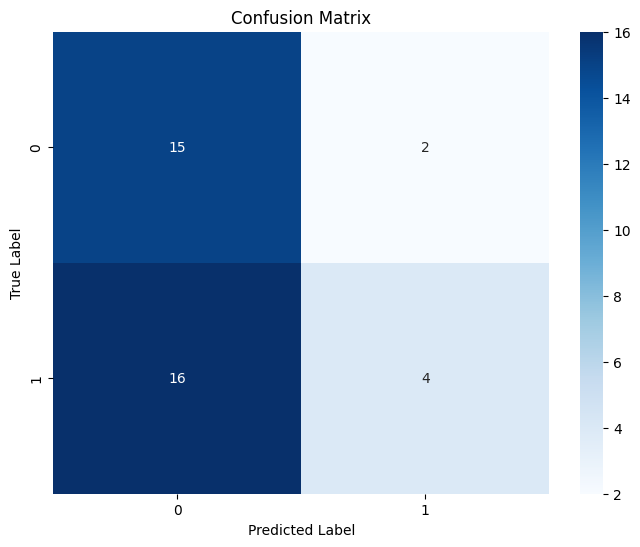

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Load model to the same device as data
model = CNN(num_classes, num_derivatives, num_subsequences, best_config).to(device)

# ✅ Ensure weights are loaded to the correct device
model.load_state_dict(torch.load("best_cnn_model.pth", map_location=device))

# ✅ Set to evaluation mode
model.eval()

# ✅ Move test data to the same device
evaluate_model(model.to(device), test_loader, num_classes)